# A/B-тест: анализ конверсии в e-commerce

## Цель анализа

Цель эксперимента: оценить влияние варианта V1 на конверсию по сравнению с контрольной группой C.

Основная метрика: конверсия (CR, Conversion Rate).

Нулевая гипотеза (H₀): конверсия в группах C и V1 одинакова.

Альтернативная гипотеза (H₁): конверсия в группах C и V1 различается.

Уровень значимости: α = 0.05.

In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import (
proportions_ztest,
confint_proportions_2indep
)
from statsmodels.stats.multitest import multipletests

In [18]:
DATA_PATH = Path("../data/ecommerce_conversion_ab_test_data.csv")

df = pd.read_csv(
DATA_PATH,
parse_dates=["date"]
)

df.head()

,TvC,date,traffic_source,device_type,browser_language,login_y_n,region,return_y_n,conversion
0,C,2021-02-14,Referrals,Mweb,Chinese,n,Southwest,y,1
1,C,2021-02-14,Direct,Iphone,English,y,West,y,0
2,C,2021-02-11,Email Marketing,Mweb,English,y,Northeast,y,0
3,C,2021-02-11,Referrals,Iphone,English,y,Southwest,n,0
4,C,2021-02-01,Referrals,Desktop,English,y,Northeast,n,0


## 1. Проверка качества данных

Перед анализом результатов эксперимента проверим структуру датасета, типы данных, пропуски, дубликаты и допустимые значения ключевых полей.

In [19]:
print(f"Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
print(f"Период: {df['date'].min().date()} — {df['date'].max().date()}")
print(f"Пропущенных значений: {df.isna().sum().sum():,}")
print(f"Полных дубликатов строк: {df.duplicated().sum():,}")

print("\nГруппы эксперимента:")
print(df["TvC"].unique())

print("\nЗначения conversion:")
print(df["conversion"].unique())

df.info()


Размер датасета: 1,048,575 строк × 9 столбцов
Период: 2021-02-01 — 2021-02-16
Пропущенных значений: 0
Полных дубликатов строк: 979,471

Группы эксперимента:
<StringArray>
['C', 'V1']
Length: 2, dtype: str

Значения conversion:
[1 0]
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   TvC               1048575 non-null  str           
 1   date              1048575 non-null  datetime64[us]
 2   traffic_source    1048575 non-null  str           
 3   device_type       1048575 non-null  str           
 4   browser_language  1048575 non-null  str           
 5   login_y_n         1048575 non-null  str           
 6   region            1048575 non-null  str           
 7   return_y_n        1048575 non-null  str           
 8   conversion        1048575 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(7)
memory

## 2. Проверка корректности эксперимента

Проверим размер экспериментальных групп и стабильность распределения трафика между C и V1 во времени.

In [20]:
group_distribution = (
    df["TvC"]
    .value_counts()
    .rename("Наблюдения")
    .to_frame()
)

group_distribution["Доля"] = (
    group_distribution["Наблюдения"] / len(df)
)

group_distribution.index.name = "Группа эксперимента"

group_distribution

,Наблюдения,Доля
Группа эксперимента,,
C,1000000,0.953675
V1,48575,0.046325


In [21]:
daily_v1_share = (
df.groupby("date")["TvC"]
.apply(lambda x: (x == "V1").mean())
)

print(
f"Доля V1 по дням: "
f"{daily_v1_share.min():.2%} — "
f"{daily_v1_share.max():.2%}"
)

Доля V1 по дням: 4.49% — 4.81%


## 3. Проверка баланса групп

Проверим, одинаково ли распределены ключевые признаки между контрольной и экспериментальной группами.

Из-за большого объёма выборки p-value может показывать статистическую значимость даже для небольших различий, поэтому дополнительно рассчитывается размер эффекта Cramér's V.

In [22]:
balance_columns = [
    "traffic_source",
    "device_type",
    "browser_language",
    "login_y_n",
    "region",
    "return_y_n"
]

balance_results = []

for column in balance_columns:
    table = pd.crosstab(df["TvC"], df[column])

    chi2, p_value, _, _ = chi2_contingency(table)

    n = table.to_numpy().sum()

    cramers_v = np.sqrt(
        chi2 /
        (
            n *
            min(
                table.shape[0] - 1,
                table.shape[1] - 1
            )
        )
    )

    balance_results.append({
        "Признак": column,
        "chi2": chi2,
        "p_value": p_value,
        "Cramer's V": cramers_v
    })

balance_results = (
    pd.DataFrame(balance_results)
      .sort_values("Cramer's V", ascending=False)
)

balance_results_display = balance_results.copy()

balance_results_display["Признак"] = (
    balance_results_display["Признак"].replace({
        "traffic_source": "Источник трафика",
        "device_type": "Тип устройства",
        "browser_language": "Язык браузера",
        "login_y_n": "Статус авторизации",
        "region": "Регион",
        "return_y_n": "Возвращаемость"
    })
)

balance_results_display = balance_results_display.rename(columns={
    "chi2": "χ²",
    "p_value": "p-value"
})

balance_results_display.round({
    "χ²": 3,
    "p-value": 6,
    "Cramer's V": 4
})

,Признак,χ²,p-value,Cramer's V
1,Тип устройства,1223.869,0.000000,0.0342
5,Возвращаемость,5.199,0.022602,0.0022
2,Язык браузера,3.355,0.500302,0.0018
4,Регион,2.410,0.660845,0.0015
0,Источник трафика,2.397,0.791921,0.0015
3,Статус авторизации,0.045,0.832782,0.0002


In [23]:
device_share = (
    pd.crosstab(
        df["device_type"],
        df["TvC"],
        normalize="columns"
    ) * 100
)

device_share["Разница, п.п."] = (
    device_share["V1"] - device_share["C"]
)

device_share.index.name = "Тип устройства"
device_share.columns.name = "Группа"

device_share.round(2)

Группа,C,V1,"Разница, п.п."
Тип устройства,,,
Android,9.98,9.11,-0.87
Desktop,20.07,26.62,6.55
Iphone,19.98,18.24,-1.74
Mweb,49.97,46.02,-3.94


## 4. Основной результат A/B-теста

Сравним конверсию контрольной и экспериментальной групп, оценим величину эффекта и проверим его статистическую значимость.


In [24]:
group_summary = (
    df.groupby("TvC")["conversion"]
    .agg(
        observations="size",
        conversions="sum",
        conversion_rate="mean"
    )
)

group_summary["conversion_rate_pct"] = (
    group_summary["conversion_rate"] * 100
)

group_summary_display = group_summary[
    ["observations", "conversions", "conversion_rate_pct"]
].rename(columns={
    "observations": "Наблюдения",
    "conversions": "Конверсии",
    "conversion_rate_pct": "Конверсия, %"
})

group_summary_display.index.name = "Группа"

group_summary_display

,Наблюдения,Конверсии,"Конверсия, %"
Группа,,,
C,1000000,100092,10.00920
V1,48575,5272,10.85332


In [25]:
c = group_summary.loc["C"]
v1 = group_summary.loc["V1"]

z_stat, p_value = proportions_ztest(
count=[v1["conversions"], c["conversions"]],
nobs=[v1["observations"], c["observations"]]
)

absolute_lift = v1["conversion_rate"] - c["conversion_rate"]
relative_lift = absolute_lift / c["conversion_rate"]

ci_low, ci_high = confint_proportions_2indep(
count1=v1["conversions"],
nobs1=v1["observations"],
count2=c["conversions"],
nobs2=c["observations"],
compare="diff",
method="newcomb"
)

print(f"Конверсия C: {c['conversion_rate']:.2%}")
print(f"Конверсия V1: {v1['conversion_rate']:.2%}")
print(f"Прирост: {absolute_lift * 100:.2f} п.п.")
print(f"Относительный прирост: {relative_lift:.2%}")
print(f"95% ДИ разницы: [{ci_low * 100:.2f}; {ci_high * 100:.2f}] п.п.")
print(f"p-value: {p_value:.3g}")

Конверсия C: 10.01%
Конверсия V1: 10.85%
Прирост: 0.84 п.п.
Относительный прирост: 8.43%
95% ДИ разницы: [0.56; 1.13] п.п.
p-value: 1.51e-09


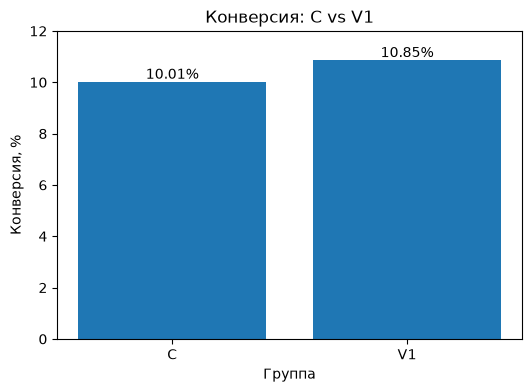

In [26]:
conversion_by_group = df.groupby('TvC')['conversion'].mean() * 100

plt.figure(figsize=(6, 4))

bars = plt.bar(
    conversion_by_group.index,
    conversion_by_group.values
)

plt.title('Конверсия: C vs V1')
plt.xlabel('Группа')
plt.ylabel('Конверсия, %')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.ylim(0, 12)
plt.show()

## 5. Динамика конверсии

Проверим, сохраняется ли наблюдаемый эффект во времени и нет ли отдельных дней, которые полностью определяют итоговый результат.

In [27]:
daily_conversion = df.groupby(['date', 'TvC'])['conversion'].mean().unstack()

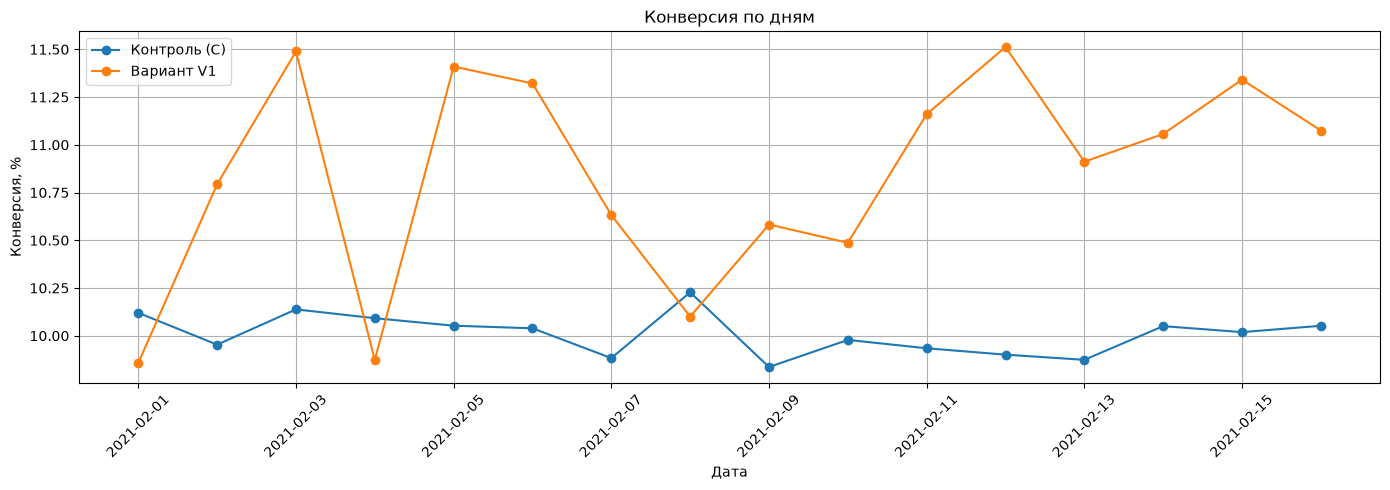

In [28]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_conversion.index,
    daily_conversion['C'] * 100,
    marker='o',
    label='Контроль (C)'
)

plt.plot(
    daily_conversion.index,
    daily_conversion['V1'] * 100,
    marker='o',
    label='Вариант V1'
)

plt.xlabel('Дата')
plt.ylabel('Конверсия, %')
plt.title('Конверсия по дням')
plt.legend()
plt.grid()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6. Исследовательский сегментный анализ

После оценки основной метрики проверим, как наблюдаемый эффект V1 различается между источниками трафика и типами устройств.

Поскольку одновременно сравнивается несколько сегментов, для p-value используется поправка Holm на множественные сравнения.


In [29]:
traffic_results = []

for source, data in df.groupby("traffic_source"):

    stats = (
        data.groupby("TvC")["conversion"]
        .agg(["sum", "count"])
    )

    conversion_c = stats.loc["C", "sum"] / stats.loc["C", "count"]
    conversion_v1 = stats.loc["V1", "sum"] / stats.loc["V1", "count"]

    z_stat, p_value = proportions_ztest(
        count=[
            stats.loc["V1", "sum"],
            stats.loc["C", "sum"]
        ],
        nobs=[
            stats.loc["V1", "count"],
            stats.loc["C", "count"]
        ]
    )

    absolute_lift = conversion_v1 - conversion_c
    relative_lift = absolute_lift / conversion_c

    traffic_results.append({
        "traffic_source": source,
        "observations_C": stats.loc["C", "count"],
        "observations_V1": stats.loc["V1", "count"],
        "conversion_C": conversion_c,
        "conversion_V1": conversion_v1,
        "absolute_lift": absolute_lift,
        "relative_lift": relative_lift,
        "p_value": p_value
    })

traffic_results = pd.DataFrame(traffic_results)

traffic_results["p_value_adj"] = multipletests(
    traffic_results["p_value"],
    method="holm"
)[1]

traffic_results["significant"] = (
    traffic_results["p_value_adj"] < 0.05
)


In [30]:
traffic_results_display = traffic_results.copy()

traffic_results_display["conversion_C"] = (
    traffic_results_display["conversion_C"] * 100
).round(2)

traffic_results_display["conversion_V1"] = (
    traffic_results_display["conversion_V1"] * 100
).round(2)

traffic_results_display["absolute_lift"] = (
    traffic_results_display["absolute_lift"] * 100
).round(2)

traffic_results_display["relative_lift"] = (
    traffic_results_display["relative_lift"] * 100
).round(2)

traffic_results_display["p_value"] = (
    traffic_results_display["p_value"]
    .apply(lambda p: "<0.0001" if p < 0.0001 else f"{p:.4f}")
)

traffic_results_display["p_value_adj"] = (
    traffic_results_display["p_value_adj"]
    .apply(lambda p: "<0.0001" if p < 0.0001 else f"{p:.4f}")
)

traffic_results_display = traffic_results_display.rename(columns={
    "traffic_source": "Источник трафика",
    "observations_C": "Наблюдения C",
    "observations_V1": "Наблюдения V1",
    "conversion_C": "CR C, %",
    "conversion_V1": "CR V1, %",
    "absolute_lift": "Прирост, п.п.",
    "relative_lift": "Относительный прирост, %",
    "p_value": "p-value",
    "p_value_adj": "p-value Holm",
    "significant": "Значимо"
})

traffic_results_display["Значимо"] = (
    traffic_results_display["Значимо"]
    .map({True: "Да", False: "Нет"})
)

traffic_results_display

,Источник трафика,Наблюдения C,Наблюдения V1,"CR C, %","CR V1, %","Прирост, п.п.","Относительный прирост, %",p-value,p-value Holm,Значимо
0,Direct,199723,9679,10.03,11.34,1.32,13.11,<0.0001,0.0002,Да
1,Email Marketing,79796,3828,9.97,9.61,-0.36,-3.57,0.4726,0.4726,Нет
2,Organic,399796,19352,10.00,10.92,0.93,9.27,<0.0001,0.0002,Да
3,Paid Search,100429,4955,10.00,10.60,0.60,5.98,0.1711,0.3421,Нет
4,Referrals,150418,7337,10.17,10.88,0.71,6.96,0.0504,0.1884,Нет
5,Social Media,69838,3424,9.74,10.78,1.03,10.60,0.0471,0.1884,Нет


### Детализация по типам устройств

Тип устройства показал наиболее заметный дисбаланс между группами. Поэтому отдельно оценим состав групп по устройствам и посмотрим, одинаков ли эффект V1 в разных сегментах по типам устройств.

In [31]:
device_results = []

for device, data in df.groupby("device_type"):

    stats = (
        data.groupby("TvC")["conversion"]
        .agg(["sum", "count"])
    )

    conversion_c = (
        stats.loc["C", "sum"] /
        stats.loc["C", "count"]
    )

    conversion_v1 = (
        stats.loc["V1", "sum"] /
        stats.loc["V1", "count"]
    )

    z_stat, p_value = proportions_ztest(
        count=[
            stats.loc["V1", "sum"],
            stats.loc["C", "sum"]
        ],
        nobs=[
            stats.loc["V1", "count"],
            stats.loc["C", "count"]
        ]
    )

    absolute_lift = conversion_v1 - conversion_c
    relative_lift = absolute_lift / conversion_c

    device_results.append({
        "device_type": device,
        "conversion_C": conversion_c,
        "conversion_V1": conversion_v1,
        "absolute_lift": absolute_lift,
        "relative_lift": relative_lift,
        "p_value": p_value
    })

device_results = pd.DataFrame(device_results)

device_results["p_value_adj"] = multipletests(
    device_results["p_value"],
    method="holm"
)[1]

device_results["significant"] = (
    device_results["p_value_adj"] < 0.05
)



In [32]:
device_results_display = device_results.copy()

for column in [
    "conversion_C",
    "conversion_V1",
    "absolute_lift",
    "relative_lift"
]:
    device_results_display[column] *= 100

device_results_display = device_results_display.round({
    "conversion_C": 2,
    "conversion_V1": 2,
    "absolute_lift": 2,
    "relative_lift": 2
})

device_results_display["p_value"] = (
    device_results_display["p_value"]
    .apply(lambda p: "<0.0001" if p < 0.0001 else f"{p:.4f}")
)

device_results_display["p_value_adj"] = (
    device_results_display["p_value_adj"]
    .apply(lambda p: "<0.0001" if p < 0.0001 else f"{p:.4f}")
)

device_results_display = device_results_display.rename(columns={
    "device_type": "Устройство",
    "conversion_C": "CR C, %",
    "conversion_V1": "CR V1, %",
    "absolute_lift": "Прирост, п.п.",
    "relative_lift": "Относительный прирост, %",
    "p_value": "p-value",
    "p_value_adj": "p-value Holm",
    "significant": "Значимо"
})

device_results_display["Значимо"] = (
    device_results_display["Значимо"]
    .map({True: "Да", False: "Нет"})
)

device_results_display

,Устройство,"CR C, %","CR V1, %","Прирост, п.п.","Относительный прирост, %",p-value,p-value Holm,Значимо
0,Android,10.06,11.50,1.44,14.29,0.0019,0.0057,Да
1,Desktop,9.94,11.52,1.59,15.97,<0.0001,<0.0001,Да
2,Iphone,10.01,10.10,0.09,0.91,0.7790,0.7790,Нет
3,Mweb,10.03,10.64,0.61,6.07,0.0031,0.0062,Да


## 7. Выводы

В эксперименте конверсия группы **V1 составила 10,85%** против **10,01%** в контрольной группе C.

**Наблюдаемый эффект V1:**
- абсолютный прирост — около **+0,84 п.п.;**
- относительный прирост — около **+8,4%;**
- различие статистически значимо: **p-value < 0,05;**
- 95%-й доверительный интервал для разницы конверсий не включает ноль.

При интерпретации результата необходимо учитывать особенности экспериментального дизайна.

Размер групп существенно различается: около **95% наблюдений относятся к C и около 5% — к V1**. При этом доля V1 оставалась относительно стабильной на протяжении теста. Без информации об ожидаемом распределении трафика такое соотношение нельзя однозначно считать ошибкой эксперимента.

Проверка баланса показала статистически значимое, но небольшое различие в составе групп по **типам устройств**. По признаку возвращаемости различие также статистически значимо, однако его величина практически незначительна.

Сегментный анализ показал, что после поправки Holm статистически значимый прирост конверсии наблюдается для **Android, Desktop и Mweb**, тогда как для **iPhone** значимого различия не обнаружено. По источникам трафика статистически значимый эффект сохраняется для **Direct и Organic**.

В данных отсутствует уникальный идентификатор пользователя, поэтому невозможно проверить, соответствует ли одна строка одному уникальному пользователю. По этой же причине полностью совпадающие строки нельзя автоматически считать ошибочными дублями и удалять.

**Итог:** вариант V1 показал статистически значимый рост конверсии и может рассматриваться как кандидат на внедрение. Рекомендуется подтвердить корректность распределения трафика и учитывать различия эффекта между типами устройств.